In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Cargamos los datos crudos desde la carpeta data/raw
df = pd.read_csv('../../data/raw/nhanes_ui_women.csv')

# Mostramos las primeras 5 filas para comprobar que cargó bien
df.head()

,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
0,109266.0,2017-March2020,NaN,29.0,5.0,2.0,37.8,2.0,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,0,none
1,109267.0,2017-March2020,NaN,21.0,2.0,2.0,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
2,109284.0,2017-March2020,NaN,44.0,1.0,2.0,39.1,2.0,NaN,NaN,...,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,1,stress
3,109286.0,2017-March2020,NaN,33.0,5.0,2.0,28.9,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
4,109290.0,2017-March2020,NaN,68.0,4.0,1.0,28.1,1.0,1.0,NaN,...,2.0,2.0,NaN,1.0,1.0,2.0,2.0,1.0,1,urge


In [2]:
# Ver cuántas filas y columnas tiene el dataset
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

# Ver información general de las columnas (tipos de datos y valores no nulos)
df.info()


El dataset tiene 9074 filas y 27 columnas.

<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_participante            9074 non-null   float64
 1   ciclo_nhanes               9074 non-null   str    
 2   peso_encuesta              4321 non-null   float64
 3   edad_anios                 9074 non-null   float64
 4   etnia                      9074 non-null   float64
 5   pais_nacimiento            9067 non-null   float64
 6   imc                        7620 non-null   float64
 7   dx_hipertension            9074 non-null   float64
 8   medicacion_hta_cicloP      1694 non-null   float64
 9   medicacion_hta_cicloL      1599 non-null   float64
 10  dx_diabetes                9074 non-null   float64
 11  dx_cancer                  9074 non-null   float64
 12  dx_artritis                9074 non-null   float64
 13  fumadora_alguna

In [3]:
# 1. Veamos cuántos duplicados totales hay
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas en el dataset: {duplicados}\n")

# 2. Veamos cuántos valores nulos (faltantes) hay por columna
print("Valores nulos por columna:")
nulos = df.isnull().sum()

# Filtra y muestra solo las columnas que SI tienen nulos, ordenadas de mayor a menor
columnas_con_nulos = nulos[nulos > 0].sort_values(ascending=False)
print(columnas_con_nulos)


Número de filas duplicadas en el dataset: 0

Valores nulos por columna:
ui_urgencia_frecuencia       7724
medicacion_hta_cicloL        7475
medicacion_hta_cicloP        7380
ui_esfuerzo_frecuencia       7339
ui_molestia_percibida        6706
ui_cantidad                  5522
ui_otro_tipo_presente        5020
ui_impacto_actividades       4861
peso_encuesta                4753
actividad_fisica_vigorosa    4321
ui_urgencia_presente         2190
ui_esfuerzo_presente         2185
ui_frecuencia                2180
imc                          1454
nivel_pobreza_familiar        905
pais_nacimiento                 7
fumadora_alguna_vez             6
dtype: int64


/var/folders/1p/w3s14y4d6h73sf2yqfjwgs2w0000gn/T/ipykernel_66685/428606414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


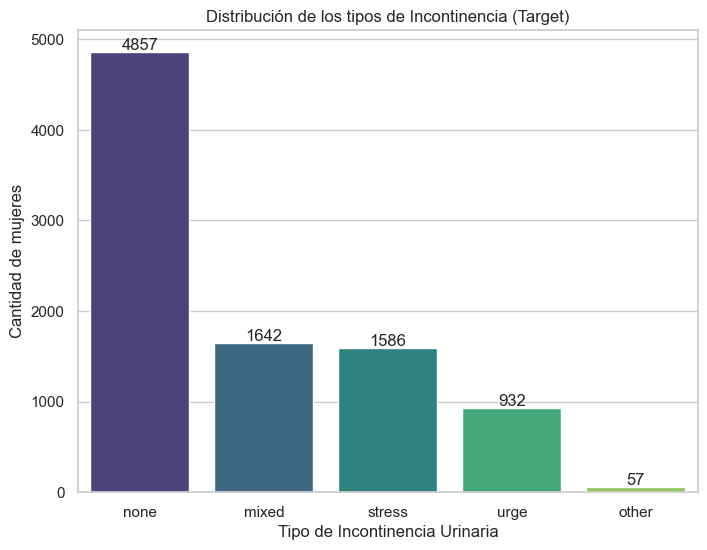


Porcentaje de cada clase en el target:
target_tipo_ui
none      53.53
mixed     18.10
stress    17.48
urge      10.27
other      0.63
Name: proportion, dtype: float64


In [4]:
# Gráfico de barras para ver la distribución de la variable objetivo (target)
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df, 
    x='target_tipo_ui', 
    order=df['target_tipo_ui'].value_counts().index,
    palette='viridis' # Le damos un poco de color
)

# Añadimos titulo y etiquetas a los ejes
plt.title('Distribución de los tipos de Incontinencia (Target)')
plt.xlabel('Tipo de Incontinencia Urinaria')
plt.ylabel('Cantidad de mujeres')

# Esto añade el numerito exacto encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show() # Mostrar el gráfico

# También los imprimimos como porcentajes para tener el dato exacto
print("\nPorcentaje de cada clase en el target:")
print(round(df['target_tipo_ui'].value_counts(normalize=True) * 100, 2))
